In [1]:
import random
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from keras.layers import Dense,InputLayer,Lambda,TextVectorization,Flatten,SimpleRNN,Reshape,Embedding,Input,Flatten,LSTM,Dropout
from keras.models import Sequential,Model
from keras.optimizers import Adam

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

2024-01-15 15:40:05.630749: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
samples = pd.read_csv('samples.csv')
samples = samples.sample(10000)

In [4]:
samples['Review'].str.len().mean()

1318.1877

In [5]:
train, test = train_test_split(samples,test_size=.2,random_state=seed)
train, val = train_test_split(train,test_size=.2,random_state=seed)

In [6]:
stop_words = []

In [7]:
max_tokens = 500
output_sequence_length = 1250

def standardize(text):
    result = tf.strings.lower(text)   
    result = tf.strings.regex_replace(result, r'<[^>]+>', '')
    result = tf.strings.regex_replace(result, r'[^a-z\s]', '')
    result = tf.strings.regex_replace(result, r'\s+', ' ')
    return result
def split(text):
    return tf.strings.split(text, ' ')

vectorizer = TextVectorization(max_tokens=max_tokens,output_sequence_length=output_sequence_length,standardize=standardize,split=split)
vectorizer.adapt(train['Review'].values)
vectorizer(train['Review'].values)

<tf.Tensor: shape=(6400, 1250), dtype=int64, numpy=
array([[ 11,  13,  61, ...,   0,   0,   0],
       [  9, 486,   6, ...,   0,   0,   0],
       [ 11, 114,   1, ...,   0,   0,   0],
       ...,
       [ 10,   7,  28, ...,   0,   0,   0],
       [ 29,   1,  51, ...,   0,   0,   0],
       [ 11, 118,  51, ...,   0,   0,   0]])>

In [8]:
x_train = vectorizer(train['Review'].values)
y_train = train['Sentiment'].values

x_val = vectorizer(val['Review'].values)
y_val = val['Sentiment'].values

x_test = vectorizer(test['Review'].values)
y_test = test['Sentiment'].values

In [9]:
input = Input(shape=(1,))
embedding = Embedding(input_dim=max_tokens,output_dim=1,input_length=output_sequence_length,mask_zero=True)(input)
rnn = SimpleRNN(1)(embedding)
hidden = Dense(64, activation='relu')(rnn)
dropout = Dropout(.25),
output = Dense(1, activation='sigmoid')(hidden)

model = Model(inputs=input,outputs=output)

optimizer = Adam(learning_rate=.001)
model.compile(optimizer=optimizer,loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train,y_train,epochs=100,batch_size=2**11,validation_data=(x_val,y_val)).history

Epoch 1/100
4/4 [==============================] - 3s 348ms/step - loss: 0.6940 - accuracy: 0.4961 - val_loss: 0.6930 - val_accuracy: 0.5150
Epoch 2/100
4/4 [==============================] - 1s 273ms/step - loss: 0.6924 - accuracy: 0.5180 - val_loss: 0.6922 - val_accuracy: 0.5250
Epoch 3/100
4/4 [==============================] - 1s 270ms/step - loss: 0.6913 - accuracy: 0.5353 - val_loss: 0.6903 - val_accuracy: 0.5400
Epoch 4/100
4/4 [==============================] - 1s 273ms/step - loss: 0.6893 - accuracy: 0.5619 - val_loss: 0.6869 - val_accuracy: 0.5894
Epoch 5/100
4/4 [==============================] - 1s 267ms/step - loss: 0.6867 - accuracy: 0.5852 - val_loss: 0.6829 - val_accuracy: 0.6144
Epoch 6/100
4/4 [==============================] - 1s 275ms/step - loss: 0.6827 - accuracy: 0.6069 - val_loss: 0.6787 - val_accuracy: 0.6263
Epoch 7/100
4/4 [==============================] - 1s 265ms/step - loss: 0.6773 - accuracy: 0.6269 - val_loss: 0.6724 - val_accuracy: 0.6444
Epoch 8/100
4

In [10]:
evalutation = model.evaluate(x_test,y_test)

63/63 [==============================] - 3s 41ms/step - loss: 0.4987 - accuracy: 0.7810


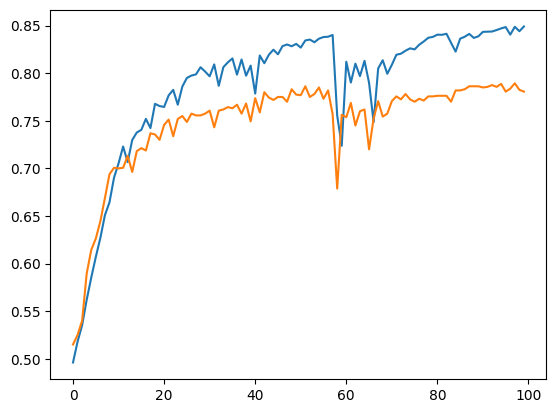

In [11]:
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.show()

In [12]:
predictions = model.predict(x_test, verbose=0)
predictions

array([[0.22333802],
       [0.250459  ],
       [0.9308748 ],
       ...,
       [0.14328323],
       [0.31002766],
       [0.869612  ]], dtype=float32)

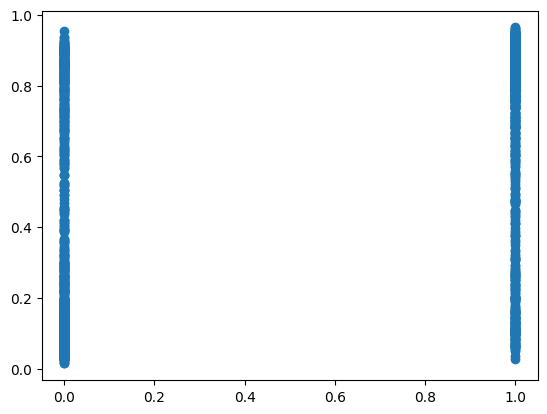

In [13]:
plt.scatter(y_test,predictions)
plt.show()

In [14]:
confusion_matrix(y_test, (predictions > .5).astype(int))

array([[737, 257],
       [181, 825]])